## Задача 1

Реализовать класс для работы с линейной регрессией

In [ ]:
import pandas as pd
import numpy as np

class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization=None, weight_calc='matrix', lambda_1=None, lambda_2=None, batch_size=20):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        # Your code here

    def fit(self, X: pd.DataFrame, y: pd.DataFrame):
        pass # Your code here

    def predict(self, X: np.array, ss=True):
        pass # Your code here

    def score(self, X: np.array, y: np.array):
        pass # Your code here

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

In [10]:
class MyLinearRegression:
    def __init__(self, regularization=None, weight_calc='matrix',
                 lambda_1=None, lambda_2=None, learning_rate=0.01,
                 max_iter=1000, batch_size=20, random_state=7):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size

        self.coef_ = None
        self.intercept_ = None
        self.n_iter_ = 0

        np.random.seed(random_state)

    def _add_intercept(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _matrix_solution(self, X, y):
        X_aug = self._add_intercept(X)

        if self.regularization is None:
            w = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y
        else:
            I = np.eye(X_aug.shape[1])
            I[0, 0] = 0
            w = np.linalg.inv(X_aug.T @ X_aug + self.lambda_2 * I) @ X_aug.T @ y

        self.intercept_ = w[0]
        self.coef_ = w[1:]
        return self

    def _gradient_method(self, X, y, method='gd'):
        X_aug = self._add_intercept(X)
        n_samples, n_features = X_aug.shape
        w = np.random.randn(n_features) * 0.01

        for epoch in range(self.max_iter):
            if method == 'sgd':
                indices = np.random.permutation(n_samples)
                X_shuffled = X_aug[indices]
                y_shuffled = y[indices]

                for i in range(0, n_samples, self.batch_size):
                    end_idx = min(i + self.batch_size, n_samples)
                    X_batch = X_shuffled[i:end_idx]
                    y_batch = y_shuffled[i:end_idx]

                    y_pred = X_batch @ w
                    error = y_pred - y_batch
                    gradient = (X_batch.T @ error) / len(X_batch)

                    if self.regularization == 'l1':
                        gradient[1:] += self.lambda_1 * np.sign(w[1:])
                    elif self.regularization == 'l2':
                        gradient[1:] += self.lambda_2 * w[1:]
                    elif self.regularization == 'l1l2':
                        gradient[1:] += self.lambda_1 * np.sign(w[1:]) + self.lambda_2 * w[1:]

                    w -= self.learning_rate * gradient
            else:
                y_pred = X_aug @ w
                error = y_pred - y
                gradient = (X_aug.T @ error) / n_samples

                if self.regularization == 'l1':
                    gradient[1:] += self.lambda_1 * np.sign(w[1:])
                elif self.regularization == 'l2':
                    gradient[1:] += self.lambda_2 * w[1:]
                elif self.regularization == 'l1l2':
                    gradient[1:] += self.lambda_1 * np.sign(w[1:]) + self.lambda_2 * w[1:]

                w -= self.learning_rate * gradient

        self.n_iter_ = self.max_iter
        self.intercept_ = w[0]
        self.coef_ = w[1:]
        return self

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).flatten()

        if self.weight_calc == 'matrix':
            return self._matrix_solution(X, y)
        elif self.weight_calc in ['gd', 'sgd']:
            return self._gradient_method(X, y, self.weight_calc)

    def predict(self, X):
        return np.array(X) @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y).flatten()

        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

        return 0.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790
...,...,...,...,...,...,...,...,...,...
375,lounge,69,manual,4474,55976,2,45.610050,9.24234,5500
376,lounge,69,manual,4200,134717,1,44.102020,9.82024,5500
377,lounge,69,manual,3470,113344,1,41.003799,16.87294,5500
378,pop,69,automatic,3712,130000,1,45.810501,8.96474,5500


In [11]:
data_path = "Used_fiat_500_in_Italy_dataset.csv"
df = pd.read_csv(data_path)

print(f"Размер датасета: {df.shape}")

df

Размер датасета: (380, 9)


,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790
...,...,...,...,...,...,...,...,...,...
375,lounge,69,manual,4474,55976,2,45.610050,9.24234,5500
376,lounge,69,manual,4200,134717,1,44.102020,9.82024,5500
377,lounge,69,manual,3470,113344,1,41.003799,16.87294,5500
378,pop,69,automatic,3712,130000,1,45.810501,8.96474,5500


In [12]:
target = 'price'

X = df.drop(target, axis=1)
y = df[target]
X = pd.get_dummies(X, drop_first=True)

print(f"Признаки после one-hot кодирования: {X.shape[1]}")
X

Признаки после one-hot кодирования: 10


,engine_power,age_in_days,km,previous_owners,lat,lon,model_pop,model_sport,model_star,transmission_manual
0,69,4474,56779,2,45.071079,7.46403,True,False,False,True
1,69,2708,160000,1,45.069679,7.70492,False,False,False,True
2,69,3470,170000,2,45.514599,9.28434,False,False,False,False
3,69,3288,132000,2,41.903221,12.49565,False,True,False,True
4,69,3712,124490,2,45.532661,9.03892,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
375,69,4474,55976,2,45.610050,9.24234,False,False,False,True
376,69,4200,134717,1,44.102020,9.82024,False,False,False,True
377,69,3470,113344,1,41.003799,16.87294,False,False,False,True
378,69,3712,130000,1,45.810501,8.96474,True,False,False,False


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"Train размер: {X_train_scaled.shape}")
print(f"Test размер: {X_test_scaled.shape}")

Train размер: (304, 10)
Test размер: (76, 10)


In [15]:
results = []

configs = [
    {'name': 'MyLR (матричный)', 'reg': None, 'method': 'matrix'},
    {'name': 'MyLR (GD)', 'reg': None, 'method': 'gd', 'lr': 0.01},
    {'name': 'MyLR (SGD)', 'reg': None, 'method': 'sgd', 'lr': 0.01, 'bs': 32},

    {'name': 'MyLR (матричный, L2)', 'reg': 'l2', 'method': 'matrix', 'l2': 1.0},
    {'name': 'MyLR (GD, L2)', 'reg': 'l2', 'method': 'gd', 'l2': 1.0, 'lr': 0.01},

    {'name': 'MyLR (GD, L1)', 'reg': 'l1', 'method': 'gd', 'l1': 0.1, 'lr': 0.01},

    {'name': 'MyLR (GD, ElasticNet)', 'reg': 'l1l2', 'method': 'gd',
     'l1': 0.1, 'l2': 0.5, 'lr': 0.01},
]

for config in configs:

    params = {
        'regularization': config['reg'],
        'weight_calc': config['method'],
        'learning_rate': config.get('lr', 0.01),
        'max_iter': 1000,
        'batch_size': config.get('bs', 20)
    }

    if config['reg'] in ['l1', 'l1l2']:
        params['lambda_1'] = config.get('l1')
    if config['reg'] in ['l2', 'l1l2']:
        params['lambda_2'] = config.get('l2')

    model = MyLinearRegression(**params)

    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - start_time

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-5)

    results.append({
        'Model': config['name'],
        'Type': 'MyLR',
        'R2': round(r2, 4),
        'MSE': round(mse, 2),
        'Train_Time': round(train_time, 4),
        'Predict_Time': round(predict_time, 6),
        'Nonzero_Coef': n_nonzero,
        'Coef': model.coef_.copy() if model.coef_ is not None else None
    })

    print(f"{config['name']:30} | R²: {r2:.4f} | Время обучения: {train_time:.3f}с")


MyLR (матричный)               | R²: 0.9012 | Время обучения: 0.013с
MyLR (GD)                      | R²: 0.9011 | Время обучения: 0.016с
MyLR (SGD)                     | R²: 0.9012 | Время обучения: 0.104с
MyLR (матричный, L2)           | R²: 0.9011 | Время обучения: 0.003с
MyLR (GD, L2)                  | R²: 0.7449 | Время обучения: 0.010с
MyLR (GD, L1)                  | R²: 0.9011 | Время обучения: 0.011с
MyLR (GD, ElasticNet)          | R²: 0.8276 | Время обучения: 0.013с


In [16]:
sklearn_models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge (alpha=1.0)', Ridge(alpha=1.0)),
    ('Lasso (alpha=0.1)', Lasso(alpha=0.1, max_iter=10000)),
    ('ElasticNet (alpha=0.1)', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)),
]

for name, model in sklearn_models:
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - start_time

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-5)

    results.append({
        'Model': name,
        'Type': 'sklearn',
        'R2': round(r2, 4),
        'MSE': round(mse, 2),
        'Train_Time': round(train_time, 4),
        'Predict_Time': round(predict_time, 6),
        'Nonzero_Coef': n_nonzero,
        'Coef': model.coef_.copy()
    })

    print(f"{name:30} | R²: {r2:.4f} | Время обучения: {train_time:.3f}с")

LinearRegression               | R²: 0.9012 | Время обучения: 0.011с
Ridge (alpha=1.0)              | R²: 0.9011 | Время обучения: 0.004с
Lasso (alpha=0.1)              | R²: 0.9012 | Время обучения: 0.002с
ElasticNet (alpha=0.1)         | R²: 0.8977 | Время обучения: 0.001с


In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print("\nТаблица результатов (сортировка по R²):")
print(results_df[['Model', 'Type', 'R2', 'MSE', 'Train_Time',
                  'Predict_Time', 'Nonzero_Coef']].to_string(index=False))


Таблица результатов (сортировка по R²):
                 Model    Type     R2        MSE  Train_Time  Predict_Time  Nonzero_Coef
      MyLR (матричный)    MyLR 0.9012  500984.48      0.0130      0.000000            10
            MyLR (SGD)    MyLR 0.9012  501053.21      0.1037      0.000000            10
      LinearRegression sklearn 0.9012  500984.48      0.0106      0.000000            10
     Lasso (alpha=0.1) sklearn 0.9012  501025.73      0.0019      0.000000            10
             MyLR (GD)    MyLR 0.9011  501454.42      0.0157      0.000991            10
  MyLR (матричный, L2)    MyLR 0.9011  501625.89      0.0027      0.000000            10
         MyLR (GD, L1)    MyLR 0.9011  501492.02      0.0110      0.000000            10
     Ridge (alpha=1.0) sklearn 0.9011  501625.89      0.0042      0.001304            10
ElasticNet (alpha=0.1) sklearn 0.8977  519034.98      0.0010      0.000000            10
 MyLR (GD, ElasticNet)    MyLR 0.8276  874661.96      0.0125      0.0

In [18]:
best_model = results_df.iloc[0]
print(f"Лучшая модель: {best_model['Model']}")
print(f"R² score: {best_model['R2']}")
print(f"MSE: {best_model['MSE']}")
print(f"Время обучения: {best_model['Train_Time']} секунд")
print(f"Ненулевых коэффициентов: {best_model['Nonzero_Coef']}")

mylr_mean = results_df[results_df['Type'] == 'MyLR']['R2'].mean()
sklearn_mean = results_df[results_df['Type'] == 'sklearn']['R2'].mean()
# Сравнение типов моделей
print(f"\nСравнение MyLR и sklearn:")
print(f"Средний R² (MyLR): {mylr_mean:.4f}")
print(f"Средний R² (sklearn): {sklearn_mean:.4f}")
print(f"Разница: {abs(mylr_mean - sklearn_mean):.4f}")

if abs(mylr_mean - sklearn_mean) < 0.05:
    print("Наши модели показывают сравнимую производительность с sklearn")
else:
    print("Наши модели отстают от sklearn")

print(f"\nАнализ эффекта регуляризации:")

for reg_type in ['без регуляризации', 'L2', 'L1', 'ElasticNet']:
    if reg_type == 'без регуляризации':
        mask = ~results_df['Model'].str.contains('L1|L2|ElasticNet')
        mask = mask & (results_df['Type'] == 'MyLR')
    else:
        mask = results_df['Model'].str.contains(reg_type)

    if mask.any():
        reg_models = results_df[mask]
        mean_r2 = reg_models['R2'].mean()
        mean_nonzero = reg_models['Nonzero_Coef'].mean()
        print(f"  • {reg_type:20}: R²={mean_r2:.4f}, ненулевых коэф.={mean_nonzero:.1f}")


Лучшая модель: MyLR (матричный)
R² score: 0.9012
MSE: 500984.48
Время обучения: 0.013 секунд
Ненулевых коэффициентов: 10

Сравнение MyLR и sklearn:
Средний R² (MyLR): 0.8683
Средний R² (sklearn): 0.9003
Разница: 0.0320
Наши модели показывают сравнимую производительность с sklearn

Анализ эффекта регуляризации:
  • без регуляризации   : R²=0.9012, ненулевых коэф.=10.0
  • L2                  : R²=0.8230, ненулевых коэф.=10.0
  • L1                  : R²=0.9011, ненулевых коэф.=10.0
  • ElasticNet          : R²=0.8627, ненулевых коэф.=10.0


In [19]:
best_mylr = results_df[results_df['Type'] == 'MyLR'].iloc[0]
best_sklearn = results_df[results_df['Type'] == 'sklearn'].iloc[0]

if best_mylr['Coef'] is not None and best_sklearn['Coef'] is not None:
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        f"{best_mylr['Model']}": best_mylr['Coef'],
        f"{best_sklearn['Model']}": best_sklearn['Coef']
    })

    coef_df['Abs_MyLR'] = np.abs(coef_df.iloc[:, 1])
    top_features = coef_df.nlargest(10, 'Abs_MyLR')[['Feature', coef_df.columns[1]]]

    print(f"\nТоп-10 важных признаков (по модели {best_mylr['Model']}):")
    print("" * 1)
    for idx, row in top_features.iterrows():
        print(f"{row['Feature']:30}: {row[1]:.4f}")

    correlation = np.corrcoef(best_mylr['Coef'], best_sklearn['Coef'])[0, 1]
    print(f"\nКорреляция коэффициентов между лучшими моделями MyLR и sklearn: {correlation:.4f}")


Топ-10 важных признаков (по модели MyLR (матричный)):

age_in_days                   : -1593.1859
km                            : -493.9996
lon                           : 249.0114
lat                           : 197.7236
model_sport                   : 101.6476
model_pop                     : 69.3637
previous_owners               : 49.8719
model_star                    : 42.0811
transmission_manual           : -40.1954
engine_power                  : 15.4557

Корреляция коэффициентов между лучшими моделями MyLR и sklearn: 1.0000


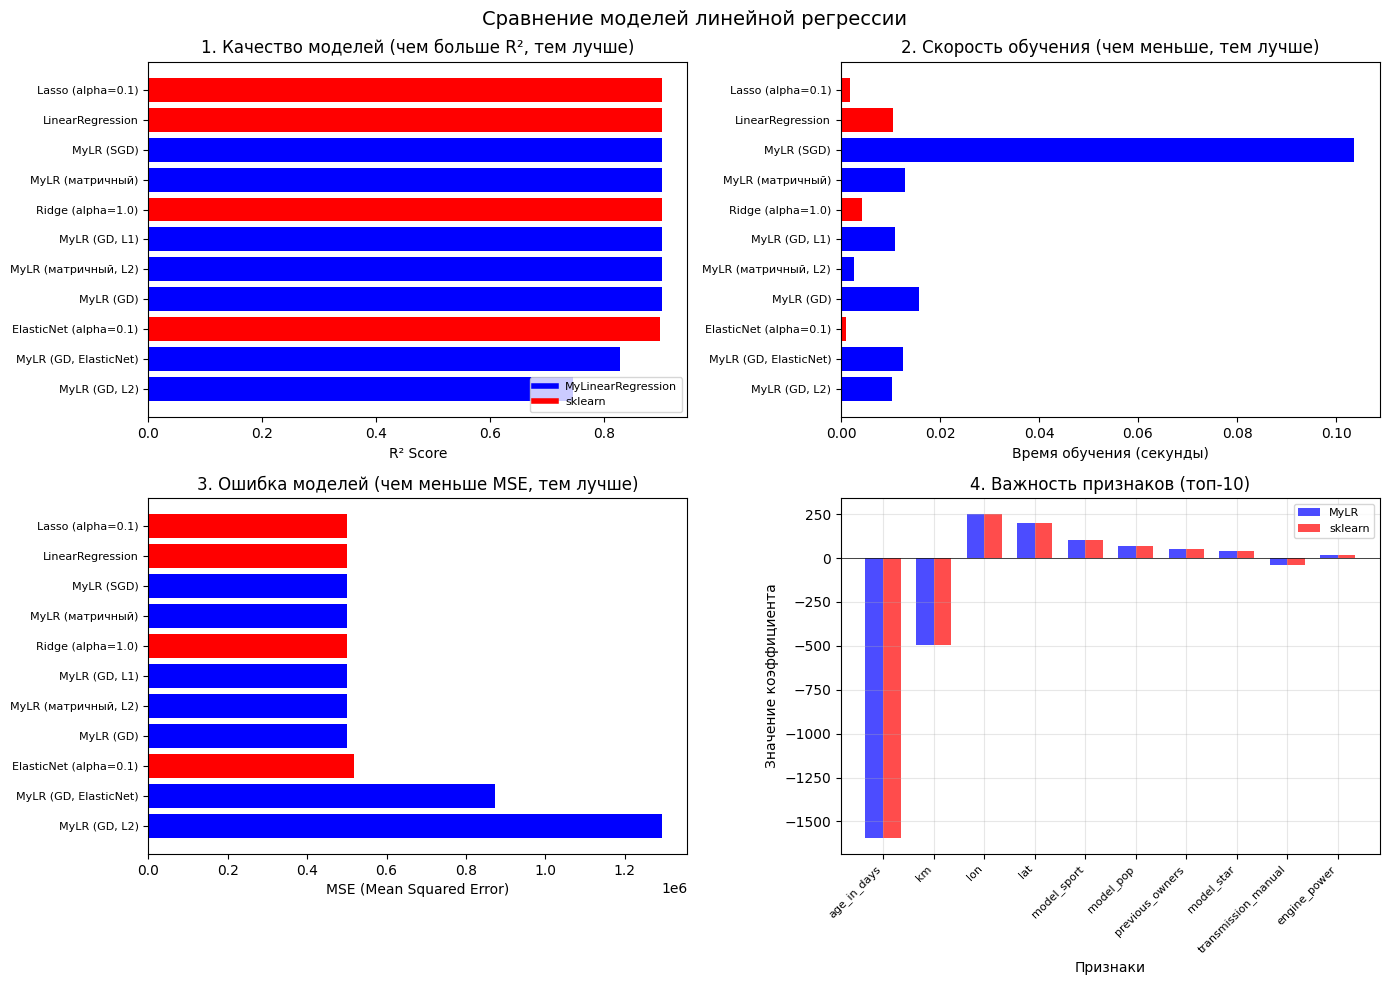

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей линейной регрессии', fontsize=14)

sorted_df = results_df.sort_values('R2')
colors = ['blue' if t == 'MyLR' else 'red' for t in sorted_df['Type']]
model_names = sorted_df['Model'].tolist()

ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(sorted_df)), sorted_df['R2'], color=colors)
ax1.set_xlabel('R² Score')
ax1.set_title('1. Качество моделей (чем больше R², тем лучше)')
ax1.set_yticks(range(len(sorted_df)))
ax1.set_yticklabels(model_names, fontsize=8)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(sorted_df)), sorted_df['Train_Time'], color=colors)
ax2.set_xlabel('Время обучения (секунды)')
ax2.set_title('2. Скорость обучения (чем меньше, тем лучше)')
ax2.set_yticks(range(len(sorted_df)))
ax2.set_yticklabels(model_names, fontsize=8)

ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(sorted_df)), sorted_df['MSE'], color=colors)
ax3.set_xlabel('MSE (Mean Squared Error)')
ax3.set_title('3. Ошибка моделей (чем меньше MSE, тем лучше)')
ax3.set_yticks(range(len(sorted_df)))
ax3.set_yticklabels(model_names, fontsize=8)

ax4 = axes[1, 1]
if best_mylr['Coef'] is not None and best_sklearn['Coef'] is not None:
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'MyLR': best_mylr['Coef'],
        'sklearn': best_sklearn['Coef']
    })

    coef_df['Abs_MyLR'] = np.abs(coef_df['MyLR'])
    top_features = coef_df.nlargest(10, 'Abs_MyLR')

    x = np.arange(len(top_features))
    width = 0.35

    bars_mylr = ax4.bar(x - width/2, top_features['MyLR'], width, label='MyLR', color='blue', alpha=0.7)
    bars_sklearn = ax4.bar(x + width/2, top_features['sklearn'], width, label='sklearn', color='red', alpha=0.7)

    ax4.set_xlabel('Признаки')
    ax4.set_ylabel('Значение коэффициента')
    ax4.set_title('4. Важность признаков (топ-10)')
    ax4.set_xticks(x)

    feature_labels = []
    for feat in top_features['Feature']:
        if len(feat) > 20:
            feature_labels.append(feat[:18] + '...')
        else:
            feature_labels.append(feat)

    ax4.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=8)
    ax4.axhline(y=0, color='black', linewidth=0.5)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=4, label='MyLinearRegression'),
    Line2D([0], [0], color='red', lw=4, label='sklearn')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)

Решено, ник: Sagot, score: 25760.89